# **SARIMA & SARIMAX**

## **IMPORTS**

In [5]:
import os
os.environ["OMP_NUM_THREADS"] = "14"
os.environ["OPENBLAS_NUM_THREADS"] = "14"
os.environ["MKL_NUM_THREADS"] = "14"

from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from typing import Union
from itertools import product
from tqdm.notebook import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
from joblib import Parallel, delayed
from statsmodels.stats.diagnostic import acorr_ljungbox

In [6]:
def train_sarima_model(y_train, p, d, q, P, D, Q, s):
    model = SARIMAX(
        endog=y_train,
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        simple_differencing=False,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)
    return fit

def train_sarimax_model(y_train, X_train, p, d, q, P, D, Q, s, log_transform=False):
    if log_transform:
        y_train = np.log1p(y_train)
    model = SARIMAX(
        endog=y_train,
        exog=X_train,
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        simple_differencing=False,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)
    return fit

def residual_analysis(fit_model, label):
    fig = fit_model.plot_diagnostics(figsize=(14, 10))
    fig.suptitle(f'Residual Diagnosis - {label}', fontsize=16)
    plt.tight_layout()
    plt.show()
    residuals = fit_model.resid.dropna()
    lb_test = acorr_ljungbox(residuals, lags=[12, 24])
    print(f"\n--- Ljung-Box Test ({label}) ---")
    print("H0: Residuals are white noise (independent).")
    print("If p-value > 0.05, the model is GOOD (no patterns remain).")
    display(lb_test)

def walk_forward_predict(fit_model, y_test, step_size=24, X_test=None, log_transform=False):
    predictions = []
    current_res = fit_model
    test_length = len(y_test)
    for i in tqdm(range(0, test_length, step_size), desc="Simulated days"):
        current_step = min(step_size, test_length - i)
        if X_test is not None:
            exog_future_chunk = X_test.iloc[i : i + current_step]
            pred = current_res.forecast(steps=current_step, exog=exog_future_chunk)
        else:
            pred = current_res.forecast(steps=current_step)
        if log_transform:
            pred = np.expm1(pred)
            actual_y_chunk_real = y_test.iloc[i : i + current_step]
            actual_y_chunk_log = np.log1p(actual_y_chunk_real)
            current_res = current_res.extend(endog=actual_y_chunk_log, exog=exog_future_chunk if X_test is not None else None, refit=False)
        else:
            actual_data_chunk = y_test.iloc[i : i + current_step]
            current_res = current_res.extend(endog=actual_data_chunk, exog=exog_future_chunk if X_test is not None else None, refit=False)
        predictions.extend(pred)
    pred_series = pd.Series(predictions, index=y_test.index)
    return pred_series

def evaluate_and_plot(y_train, y_test, predictions, label):
    wmape = np.sum(np.abs(y_test - predictions)) / np.sum(y_test)
    print(f"WMAPE ({label}): {wmape * 100:.2f}%")
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(y_train.index[-168:], y_train.iloc[-168:], label='Train (Last week)', color='gray')
    ax.plot(y_test.index, y_test, label='Test (Reality)', color='blue')
    ax.plot(y_test.index, predictions, label=f'{label} (24h)', color='green', linestyle='--')
    ax.axvspan(y_test.index[0], y_test.index[-1], color='#808080', alpha=0.1)
    ax.set_title(f'Walk-Forward Prediction (24h) vs Reality - {label}', fontsize=16)
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Number of Rentals')
    ax.legend(loc='upper left')
    ax.set_xlim(y_train.index[-168], y_test.index[168])
    plt.tight_layout()
    plt.show()

## **DATASET LOADING**

In [7]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df_original = bike_sharing.data.original

# Check all variables
X = df_original.drop(["cnt", "casual", "registered", "instant", "dteday", "atemp", "hr", "season", "weekday"], axis="columns")

y_casual = df_original["casual"]
y_registered = df_original["registered"]


# variable information 
print(bike_sharing.variables)

print(df_original.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

In [8]:
# 1. Define where we make the cut (Cut-off point). 
# For example, use 80% of historical data for training and save 20% final for testing.
split_index = int(len(df_original) * 0.80)

# 2. Split exogenous variables matrix (X)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# 3. Split target variables (y) - Casual Users
y_casual_train = y_casual.iloc[:split_index]
y_casual_test = y_casual.iloc[split_index:]

# 4. Split target variables (y) - Registered Users
y_registered_train = y_registered.iloc[:split_index]
y_registered_test = y_registered.iloc[split_index:]

print(f"Training size: {len(y_casual_train)} hours")
print(f"Test size: {len(y_casual_test)} hours")

Training size: 13903 hours
Test size: 3476 hours


## **SARIMA**

We are looking for: (p, d, q) * (P, D, Q, s)

We already know that s = 24, as the main seasonality is hourly (we know this due to the analysis we made in deliverable 1)

### Check Stationary (ADF test) --> d

In [6]:
def adf_test(y):
    ADF_result = adfuller(y)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}') #if <0.05 stationary
    print(ADF_result)

In [7]:
print("ADF CASUAL TEST..............")
adf_test(y_casual_train)

print("\nADF REGISTERED TEST..............")
adf_test(y_registered_train)

#both stationary

ADF CASUAL TEST..............
ADF Statistic: -12.349734854771963
p-value: 5.862140334336988e-23
(np.float64(-12.349734854771963), np.float64(5.862140334336988e-23), 42, 13860, {'1%': np.float64(-3.4308218983783987), '5%': np.float64(-2.8617485574092236), '10%': np.float64(-2.5668810102936184)}, np.float64(112087.83190065622))

ADF REGISTERED TEST..............
ADF Statistic: -7.4455733965650674
p-value: 5.850617439283626e-11
(np.float64(-7.4455733965650674), np.float64(5.850617439283626e-11), 42, 13860, {'1%': np.float64(-3.4308218983783987), '5%': np.float64(-2.8617485574092236), '10%': np.float64(-2.5668810102936184)}, np.float64(147261.09601416928))


This means that we already have the d parameter for both time series, d = 0

### Seasonal Difference (ACF Plots) --> D

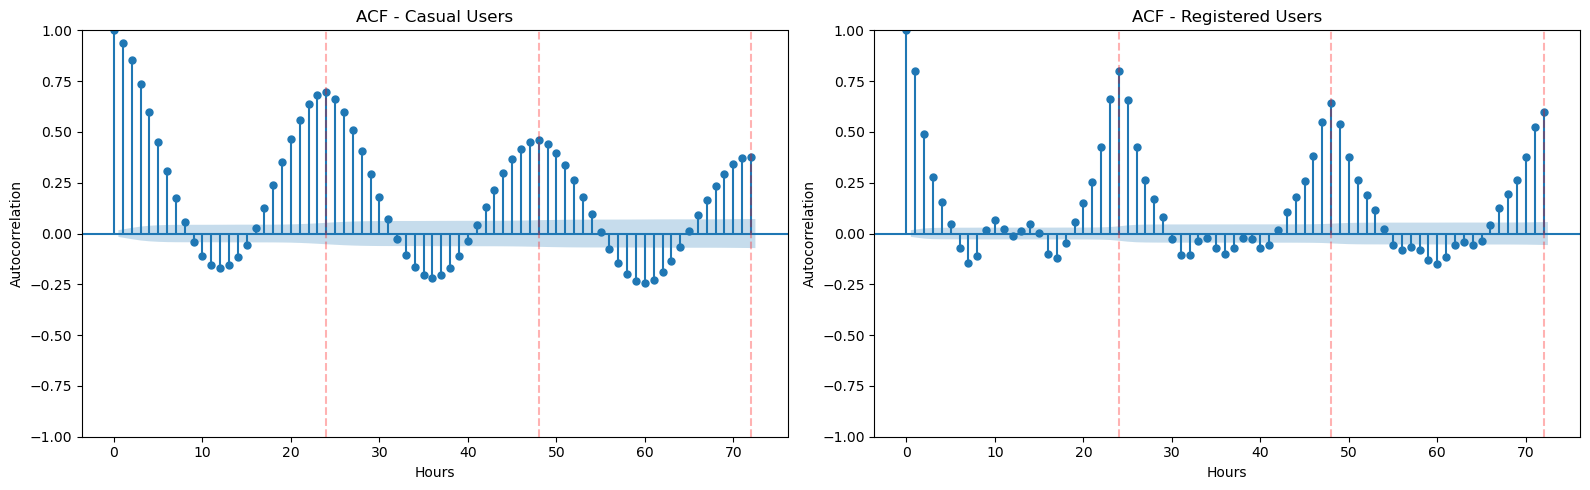

In [10]:
# 1 line, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Casual users (lags=72 to check 3 days)
plot_acf(y_casual_train, lags=72, ax=axes[0], title='ACF - Casual Users')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')

# Add lines every 24 hours, which is our s
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='red', linestyle='--', alpha=0.3)

# Same for registered users
plot_acf(y_registered_train, lags=72, ax=axes[1], title='ACF - Registered Users')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

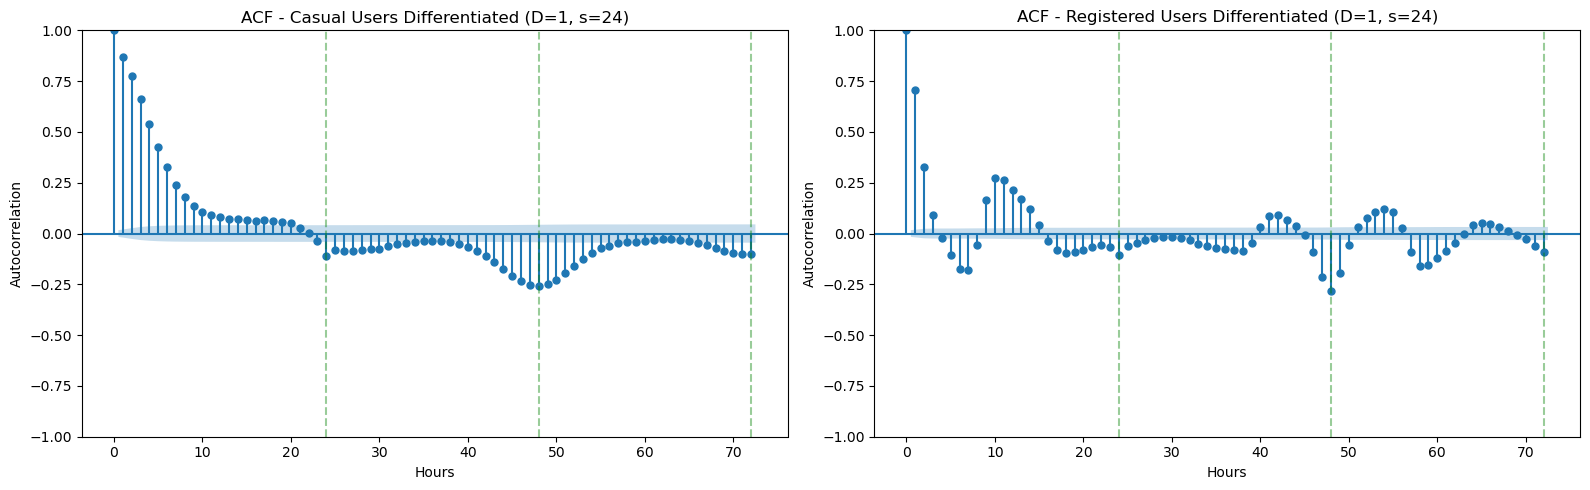

In [11]:
# Subtract from each value, the value from 24 hours ago
y_casual_diff = y_casual_train.diff(periods=24).dropna()
y_registered_diff = y_registered_train.diff(periods=24).dropna()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(y_casual_diff, lags=72, ax=axes[0], title='ACF - Casual Users Differentiated (D=1, s=24)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='green', linestyle='--', alpha=0.4) # Changed to green to differentiate it

plot_acf(y_registered_diff, lags=72, ax=axes[1], title='ACF - Registered Users Differentiated (D=1, s=24)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='green', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

This means that we already have the D parameter for both time series, D = 1

### Applying AIC (Grid Search) --> p,q,P,Q

In [9]:
# Ignore convergence warnings
warnings.filterwarnings("ignore")

# NEW: Helper function. Joblib needs us to isolate the work of a single model.
def _fit_single_model(order, endog, d, D, s):
    try:
        model = SARIMAX(
            endog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False,
            # Small extra trick so it doesn't get stuck looking for mathematical perfection:
            enforce_stationarity=False, 
            enforce_invertibility=False
        ).fit(disp=False)
        return [order, model.aic]
    except Exception:
        # If it fails, returns None so we ignore it later
        return None

def optimize_SARIMA_fast(endog: pd.Series, order_list: list, d: int, D: int, s: int, n_jobs: int = 8) -> pd.DataFrame:
    """
    Optimizes SARIMA using multiprocessing.
    n_jobs = -1 means "Use absolutely all available CPU cores".
    """
    print(f"Launching {len(order_list)} models in parallel...")
    
    # NEW: Parallelization magic. This launches the models simultaneously.
    # We use tqdm to keep the progress bar alive
    results = list(tqdm(
    Parallel(n_jobs=n_jobs, return_as="generator")(
        delayed(_fit_single_model)(order, endog, d, D, s) 
        for order in order_list
    ),
    total=len(order_list),
    desc="Evaluating combinations"
))

    # Clean up models that failed (those that returned None)
    valid_results = [r for r in results if r is not None]

    result_df = pd.DataFrame(valid_results, columns=['(p,q,P,Q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

#### *Casual*

In [11]:
# We maintain the ranges [0, 1, 2] which give 81 combinations
ps = range(0, 3, 1) 
qs = range(0, 3, 1) 
Ps = range(0, 3, 1) 
Qs = range(0, 3, 1) 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))

d_val = 0
D_val = 1
s_val = 24

# THE DATA TRICK: We take only the last 1500 rows of training
# This represents approximately the last 60 days of history.
y_casual_subset = y_casual_train.iloc[-1500:]

print("Starting ULTRA FAST Grid Search for CASUAL users...")
# Call the new parallelized function
result_casual_fast = optimize_SARIMA_fast(y_casual_subset, SARIMA_order_list, d_val, D_val, s_val, n_jobs=8)

display(result_casual_fast.head())

Starting ULTRA FAST Grid Search for CASUAL users...
Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 1, 2)",12204.827130
1,"(2, 2, 2, 2)",12206.781354
2,"(2, 2, 0, 2)",12207.897005
3,"(1, 2, 1, 2)",12211.620189
4,"(1, 2, 2, 2)",12213.550432


#### *Registered*

In [12]:
# Now for the registered users

# THE DATA TRICK: We take only the last 1500 rows of training
# This represents approximately the last 60 days of history.
y_registered_subset = y_registered_train.iloc[-1500:]

print("Starting ULTRA FAST Grid Search for REGISTERED users...")
# Call the new parallelized function
result_registered_fast = optimize_SARIMA_fast(y_registered_subset, SARIMA_order_list, d_val, D_val, s_val)

display(result_registered_fast.head())

Starting ULTRA FAST Grid Search for REGISTERED users...
Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 2, 2)",15612.938679
1,"(1, 2, 2, 2)",15625.317343
2,"(2, 0, 2, 2)",15626.973385
3,"(2, 1, 2, 2)",15628.775840
4,"(0, 2, 2, 2)",15648.416415


### Residual analysis

#### *Casual*

Training final CASUAL model with: (p=2, d=0, q=2) x (P=1, D=1, Q=2, s=24)


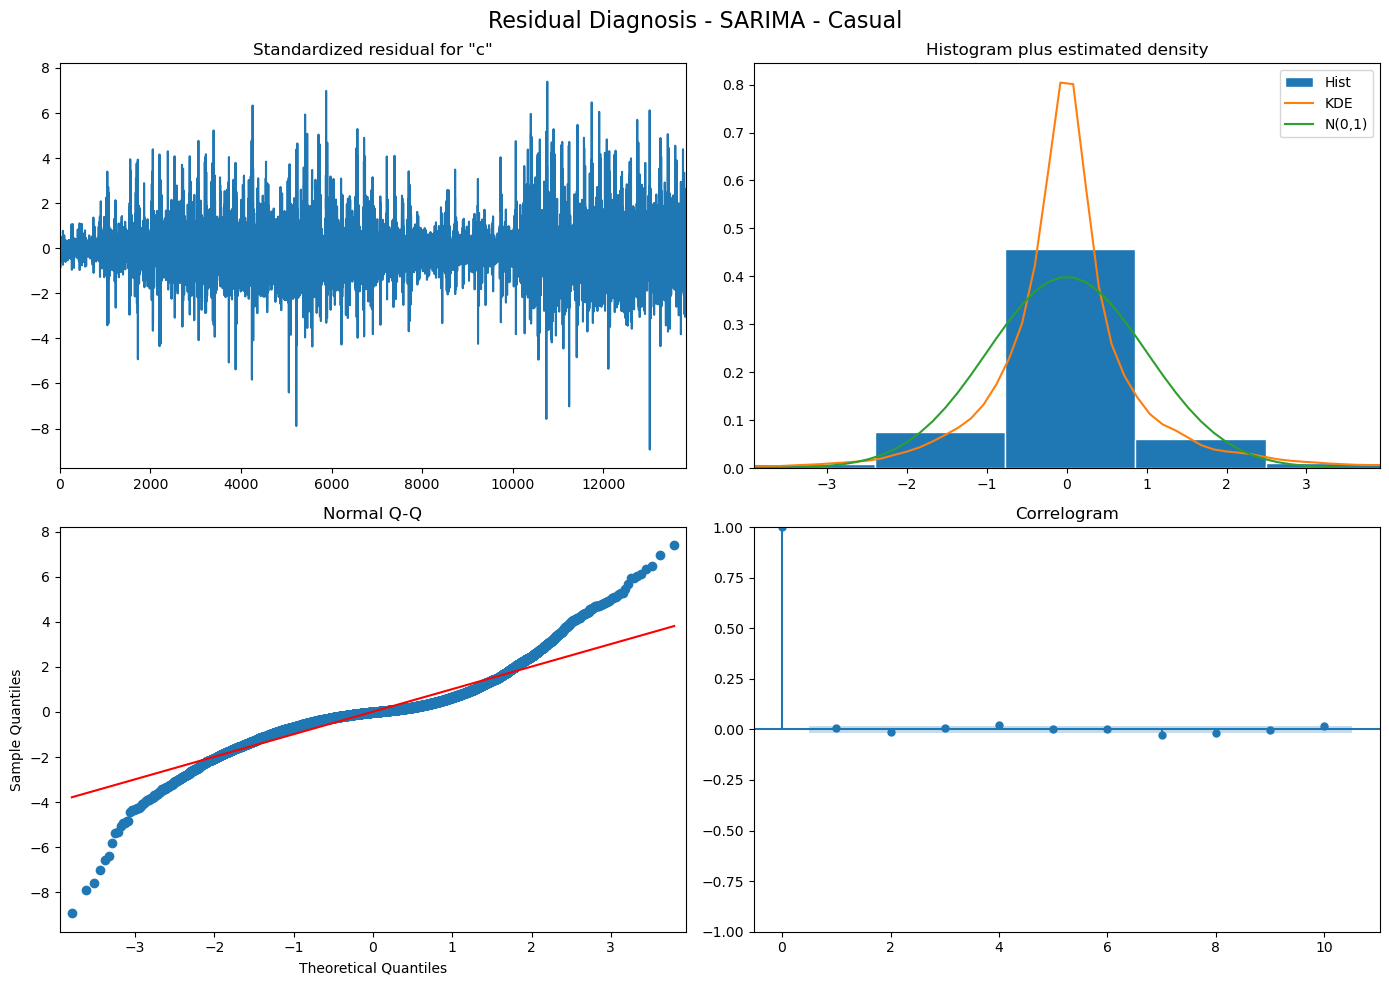


--- Ljung-Box Test (SARIMA - Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,42.470137,2.775173e-05
24,390.536881,6.558925e-68


In [12]:
# 1. Retrieve the best parameters from the Grid Search for casual users
best_p_casual, best_q_casual, best_P_casual, best_Q_casual = result_casual_fast.iloc[0]['(p,q,P,Q)']
best_p_casual, best_q_casual, best_P_casual, best_Q_casual = int(best_p_casual), int(best_q_casual), int(best_P_casual), int(best_Q_casual) 

print(f"Training final CASUAL model with: (p={best_p_casual}, d=0, q={best_q_casual}) x (P={best_P_casual}, D=1, Q={best_Q_casual}, s=24)")

# 2. Train the final model
fit_casual_final = train_sarima_model(y_casual_train, best_p_casual, 0, best_q_casual, best_P_casual, 1, best_Q_casual, 24)

# 3. Qualitative Diagnosis (The 4 plots)
residual_analysis(fit_casual_final, "SARIMA - Casual")

#### *Registered*

Training final REGISTERED model with: (p=2, d=0, q=2) x (P=2, D=1, Q=2, s=24)


c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


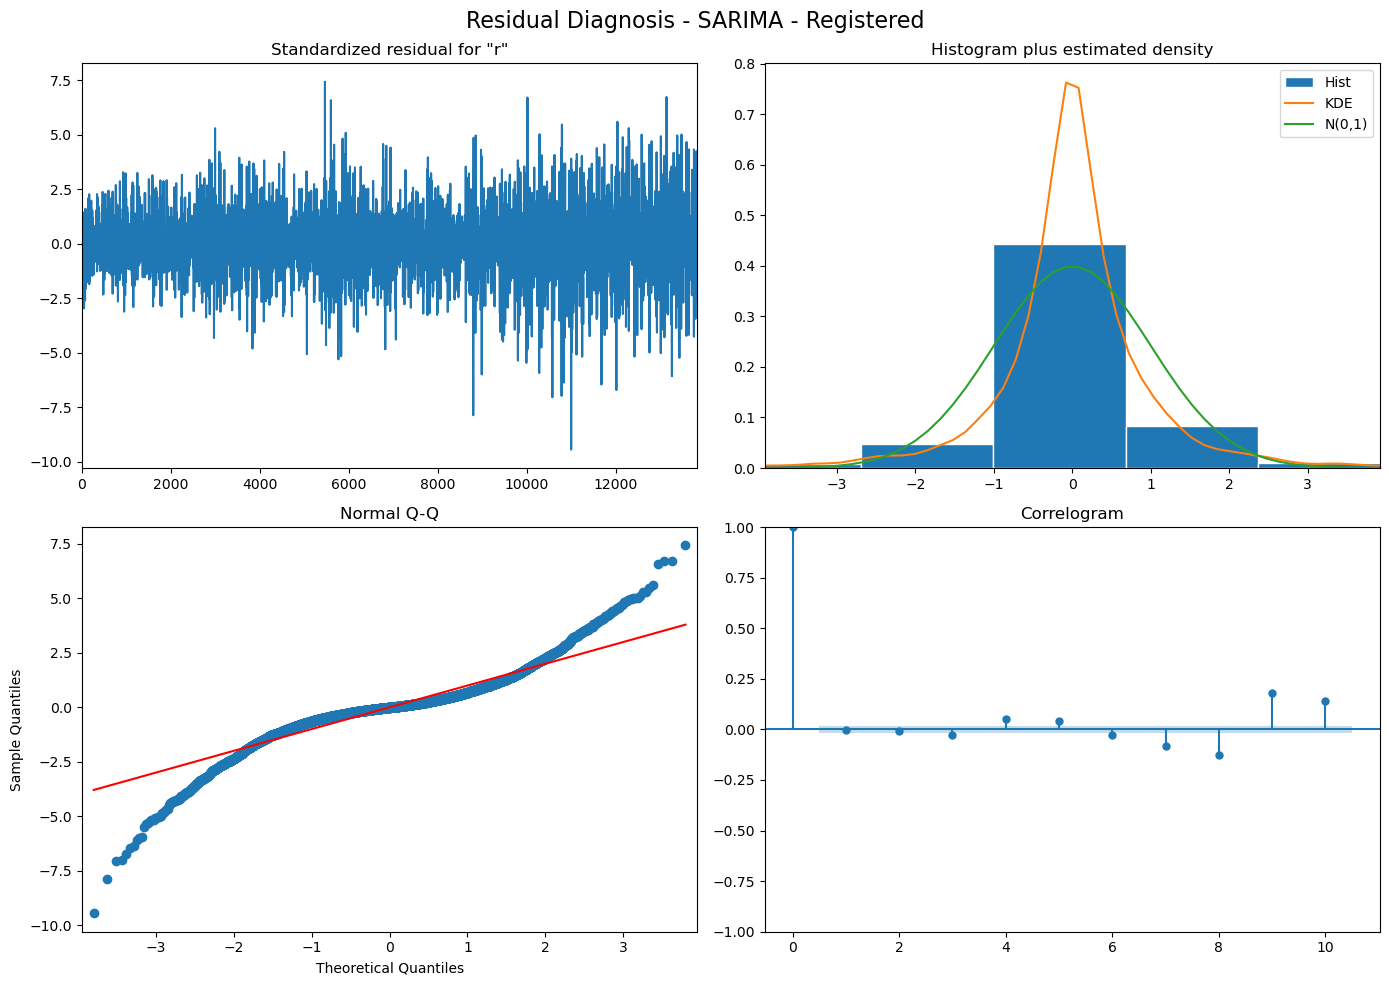


--- Ljung-Box Test (SARIMA - Registered) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,1157.265343,2.751819e-240
24,1382.426248,2.828051e-277


In [13]:
# 1. Retrieve the best parameters from the Grid Search for registered users
best_p_registered, best_q_registered, best_P_registered, best_Q_registered = result_registered_fast.iloc[0]['(p,q,P,Q)']
best_p_registered, best_q_registered, best_P_registered, best_Q_registered = int(best_p_registered), int(best_q_registered), int(best_P_registered), int(best_Q_registered) 

print(f"Training final REGISTERED model with: (p={best_p_registered}, d=0, q={best_q_registered}) x (P={best_P_registered}, D=1, Q={best_Q_registered}, s=24)")

# 2. Train the final model
fit_registered_final = train_sarima_model(y_registered_train, best_p_registered, 0, best_q_registered, best_P_registered, 1, best_Q_registered, 24)

# 3. Qualitative Diagnosis (The 4 plots)
residual_analysis(fit_registered_final, "SARIMA - Registered")

### Results

#### *Casual*

Simulated days:   0%|          | 0/145 [00:00<?, ?it/s]

c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['refit']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['refit']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['refit']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarni

WMAPE (SARIMA - Casual): 42.62%


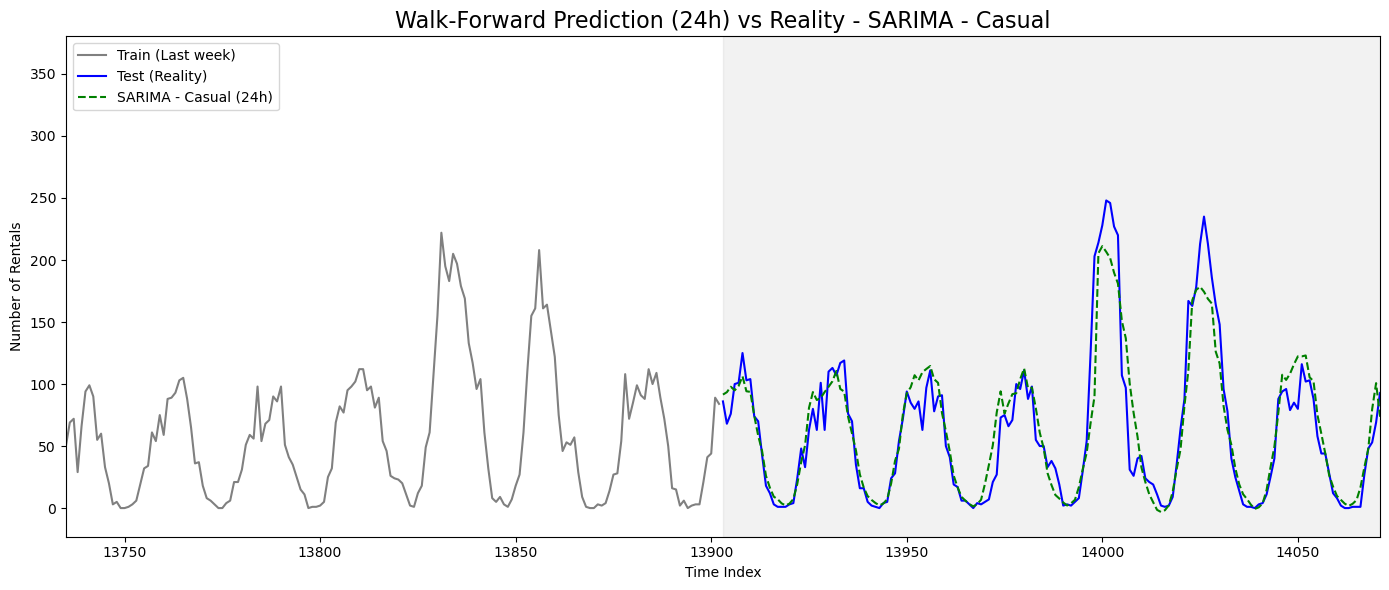

In [14]:
pred_casual = walk_forward_predict(fit_casual_final, y_casual_test, step_size=24)
evaluate_and_plot(y_casual_train, y_casual_test, pred_casual, "SARIMA - Casual")

#### *Registered*

Simulated days:   0%|          | 0/145 [00:00<?, ?it/s]

c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['refit']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['refit']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['refit']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\iker\anaconda3\envs\bike-sharing\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarni

WMAPE (SARIMA - Registered): 30.18%


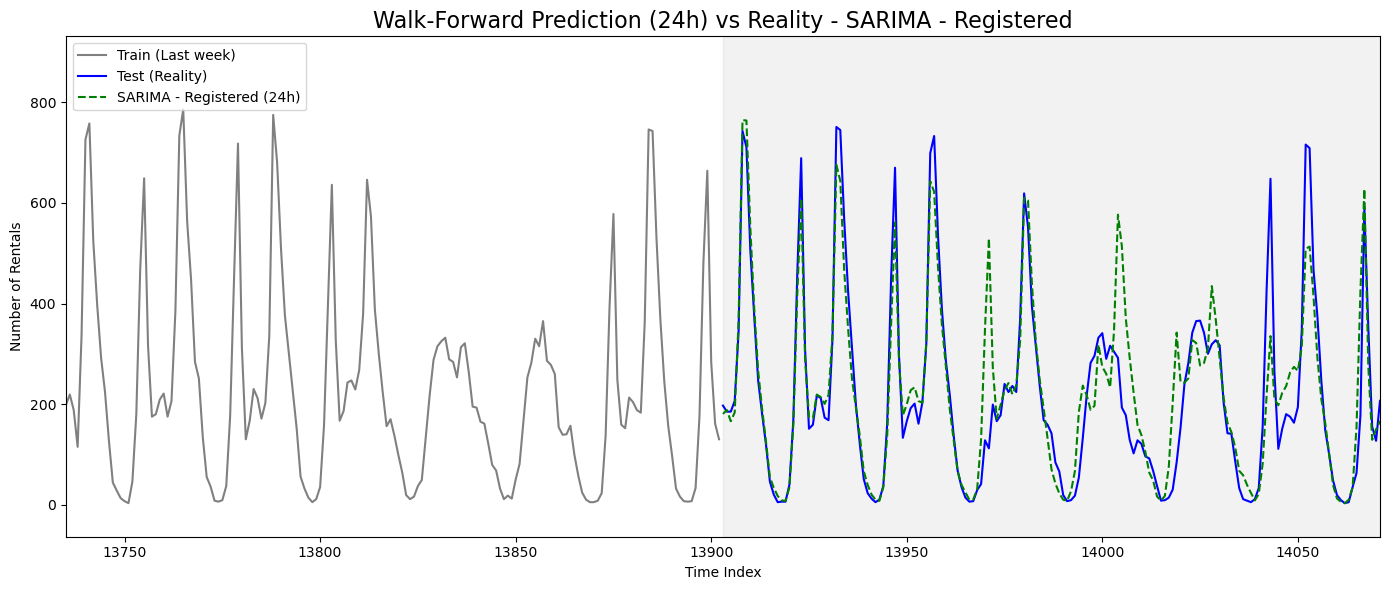

In [15]:
pred_registered = walk_forward_predict(fit_registered_final, y_registered_test, step_size=24)
evaluate_and_plot(y_registered_train, y_registered_test, pred_registered, "SARIMA - Registered")

#### *Combined*

--- RENDIMIENTO GLOBAL SARIMA (Casual + Registered) ---
MAE Global:        72.15 bikes/hour
WMAPE Global:      29.00%
Forecast Accuracy: 71.00%


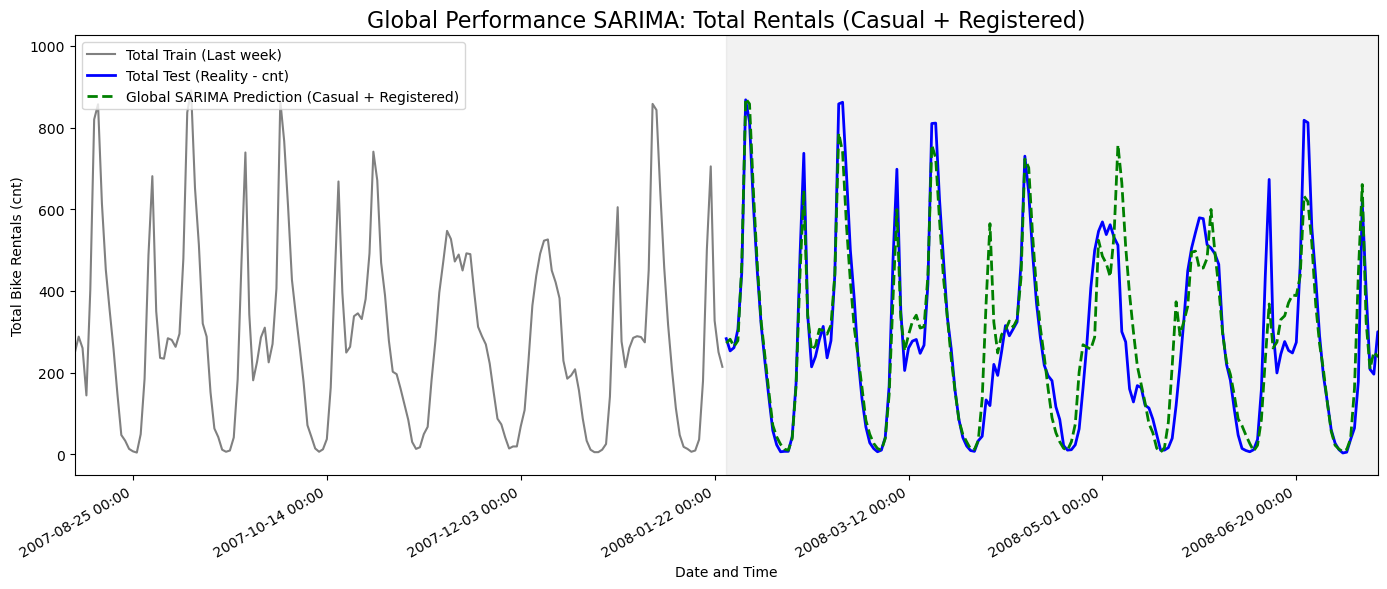

In [16]:
import matplotlib.dates as mdates
# 1. SERIES GLOBALES
total_pred_series_sarima = pred_casual + pred_registered
y_total_test = y_casual_test + y_registered_test
y_total_train = y_casual_train + y_registered_train

# 2. MÉTRICAS GLOBALES
mae_total_sarima = np.sum(np.abs(y_total_test - total_pred_series_sarima)) / len(y_total_test)
wmape_total_sarima = np.sum(np.abs(y_total_test - total_pred_series_sarima)) / np.sum(y_total_test)

print("--- RENDIMIENTO GLOBAL SARIMA (Casual + Registered) ---")
print(f"MAE Global:        {mae_total_sarima:.2f} bikes/hour")
print(f"WMAPE Global:      {wmape_total_sarima * 100:.2f}%")
print(f"Forecast Accuracy: {100 - (wmape_total_sarima * 100):.2f}%")

# 3. VISUALIZACIÓN
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_total_train.index[-168:], y_total_train.iloc[-168:],
        label='Total Train (Last week)', color='gray')
ax.plot(y_total_test.index, y_total_test,
        label='Total Test (Reality - cnt)', color='blue', linewidth=2)
ax.plot(total_pred_series_sarima.index, total_pred_series_sarima,
        label='Global SARIMA Prediction (Casual + Registered)', color='green', linestyle='--', linewidth=2)

ax.axvspan(y_total_test.index[0], y_total_test.index[-1], color='#808080', alpha=0.1)
ax.set_title('Global Performance SARIMA: Total Rentals (Casual + Registered)', fontsize=16)
ax.set_xlabel('Date and Time')
ax.set_ylabel('Total Bike Rentals (cnt)')
ax.legend(loc='upper left')
ax.set_xlim(y_total_train.index[-168], y_total_test.index[168])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## **SARIMAX**

We are looking for: (p, d, q) * (P, D, Q, s) + we add exogenous variables 

We already have the results of the SARIMA model, so we will use them. Even though SARIMAX adds exogenous variables, the basis of the model is the same. We could consider doing an extensive search again (as grid search), but taking into account the time we needed to execute the previous one, and that now we are adding a huge matrix with all the exogenous variables (which would make things a lot slower), we will use the already calculated values.

* Casual Users:
    * p, d, q = 2, 0, 2
    * P, D, Q = 1, 1, 2
    * s = 24

* Registered Users:
    * p, d, q = 2, 0, 2
    * P, D, Q = 2, 1, 2
    * s = 24

### Training

#### *Casual*

In [17]:
print("Training FINAL SARIMAX model (Casual) with exogenous variables...")

# The big difference: We add exog=X_train
fit_sarimax_casual = train_sarimax_model(y_casual_train, X_train, best_p_casual, 0, best_q_casual, best_P_casual, 1, best_Q_casual, 24, log_transform=False)

print("Training completed.")

Training FINAL SARIMAX model (Casual) with exogenous variables...
Training completed.


#### *Registered*

In [18]:
fit_sarimax_registered = train_sarimax_model(
    y_registered_train, X_train,
    best_p_registered, 0, best_q_registered,
    best_P_registered, 1, best_Q_registered,
    24, log_transform=False
)
print("Training completed.")

Training completed.


### Residual analysis

#### *Casual*

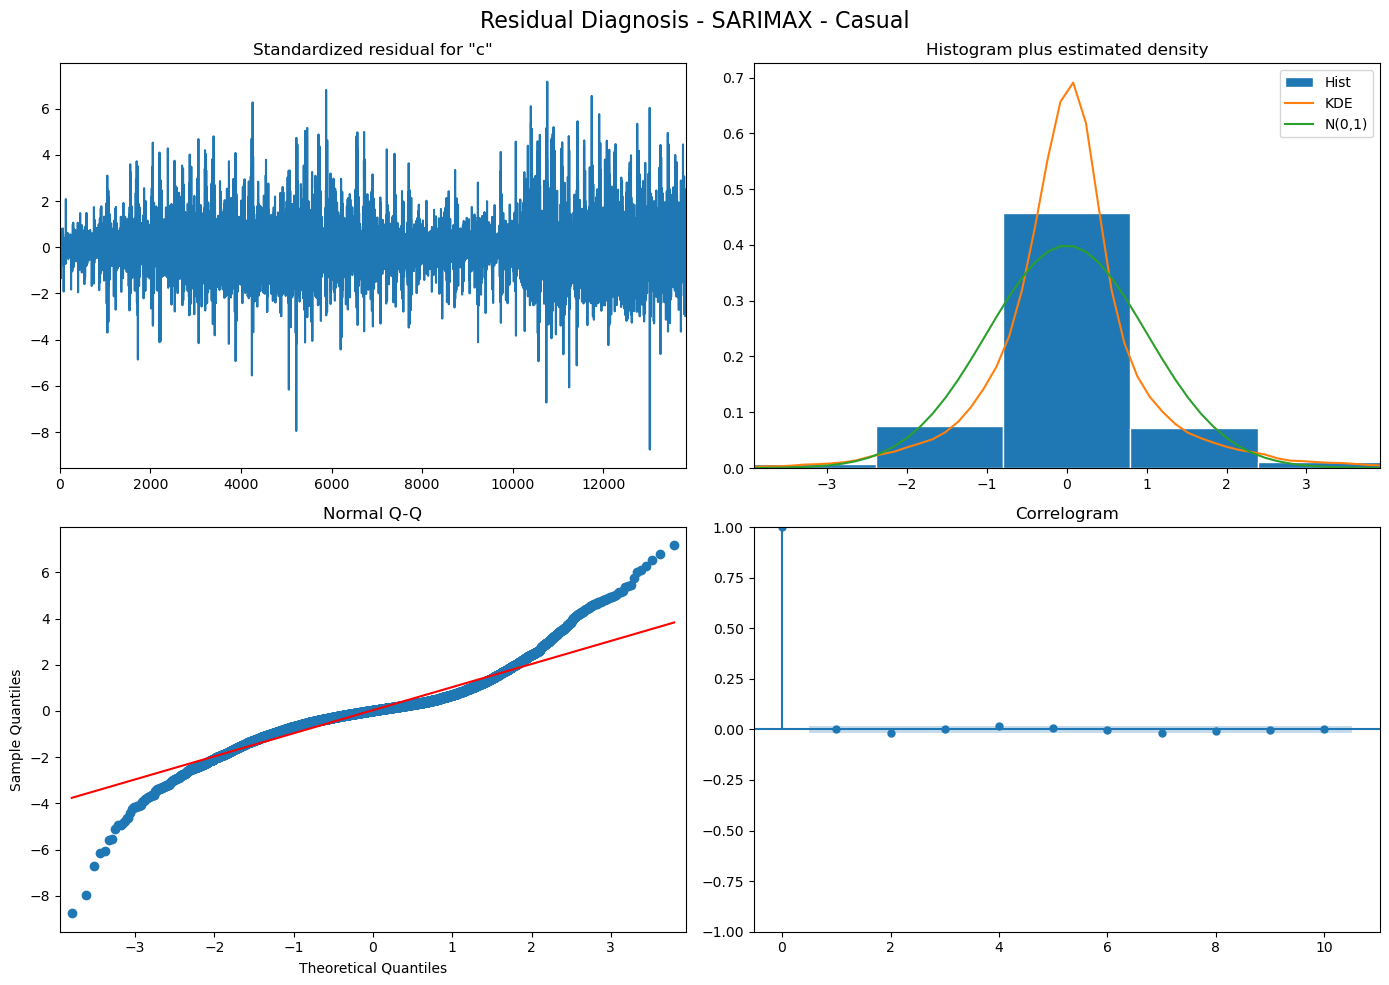


--- Ljung-Box Test (SARIMAX - Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,30.879713,2.054927e-03
24,341.734237,6.027761e-58


In [19]:
residual_analysis(fit_sarimax_casual, "SARIMAX - Casual")

#### *Registered*

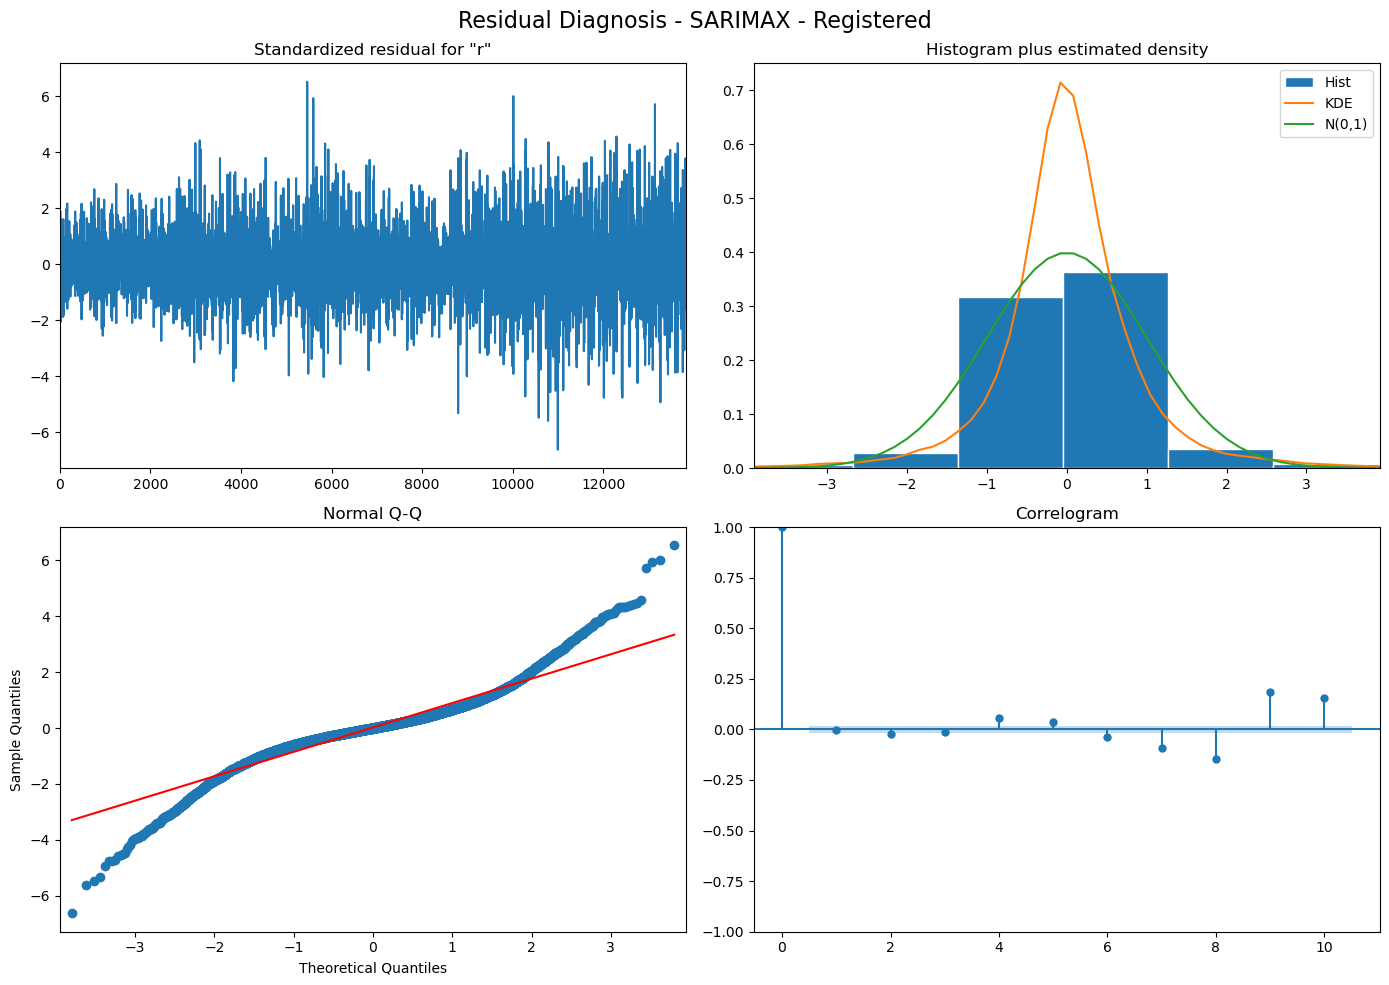


--- Ljung-Box Test (SARIMAX - Registered) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,1341.534753,5.576384e-280
24,1756.796035,0.000000e+00


In [20]:
residual_analysis(fit_sarimax_registered, "SARIMAX - Registered")

### Retrain

#### *Casual*

In [12]:
# We maintain the ranges [0, 1, 2] which give 81 combinations
ps = range(0, 3, 1) 
qs = range(0, 3, 1) 
Ps = range(0, 3, 1) 
Qs = range(0, 3, 1) 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))

d_val = 0
D_val = 1
s_val = 24

# 1. Creamos el subset logarítmico (1500 filas)
y_subset_log = np.log1p(y_casual_train.iloc[-1500:])

# 2. Buscamos los parámetros (¡SIN matriz X!)
resultados_log = optimize_SARIMA_fast(
    endog=y_subset_log, 
    order_list=SARIMA_order_list, 
    d=d_val, 
    D=D_val, 
    s=s_val, 
)
# Apuntas los parámetros ganadores que salgan el top 1

display(resultados_log.head())

Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(1, 2, 0, 2)",1778.399692
1,"(1, 2, 1, 2)",1780.356269
2,"(2, 2, 0, 2)",1780.398107
3,"(2, 2, 1, 2)",1782.353677
4,"(1, 2, 2, 2)",1782.392157


In [10]:
# We reuse the winning hyperparameters from the fast Grid Search
best_p_log, best_q_log, best_P_log, best_Q_log = resultados_log.iloc[0]['(p,q,P,Q)']
best_p_log, best_q_log, best_P_log, best_Q_log = int(best_p_log), int(best_q_log), int(best_P_log), int(best_Q_log)

fit_sarimax_log = train_sarimax_model(y_casual_train, X_train, best_p_log, 0, best_q_log, best_P_log, 1, best_Q_log, 24, log_transform=True)

print("Training completed.")

Training completed.


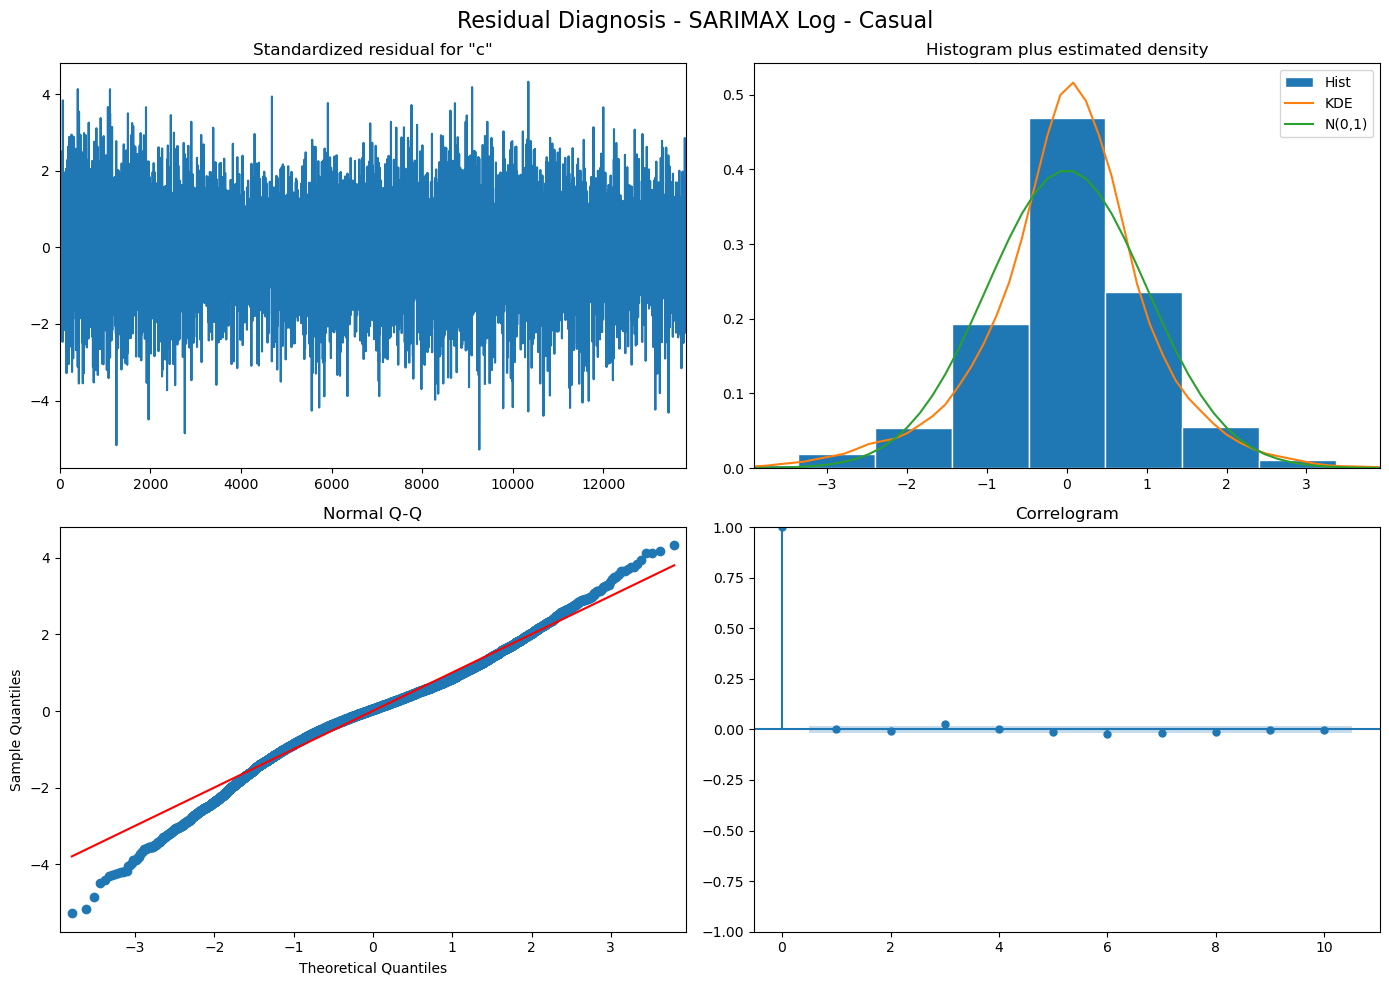


--- Ljung-Box Test (SARIMAX Log - Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,26.752859,8.385459e-03
24,430.979853,3.184909e-76


In [11]:
residual_analysis(fit_sarimax_log, "SARIMAX Log - Casual")

#### *Registered*

In [15]:
# 1. Creamos el subset logarítmico (1500 filas)
y_subset_log_registered = np.log1p(y_registered_train.iloc[-1500:])

# 2. Buscamos los parámetros (¡SIN matriz X!)
resultados_log_registered = optimize_SARIMA_fast(
    endog=y_subset_log_registered, 
    order_list=SARIMA_order_list, 
    d=d_val, 
    D=D_val, 
    s=s_val, 
)
# Apuntas los parámetros ganadores que salgan el top 1

display(resultados_log_registered.head())

Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 2, 2)",725.188293
1,"(2, 2, 2, 1)",734.506145
2,"(2, 2, 1, 2)",750.976236
3,"(2, 1, 2, 2)",759.239032
4,"(2, 1, 2, 1)",762.041990


In [12]:
#best_p_log_registered, best_q_log_registered, best_P_log_registered, best_Q_log_registered = resultados_log_registered.iloc[0]['(p,q,P,Q)']
#best_p_log_registered, best_q_log_registered, best_P_log_registered, best_Q_log_registered = int(best_p_log_registered), int(best_q_log_registered), int(best_P_log_registered), int(best_Q_log_registered)

fit_sarimax_log_registered = train_sarimax_model(y_registered_train, X_train, 2, 0, 2, 2, 1, 2, 24, log_transform=True)

print("Training completed.")

Training completed.


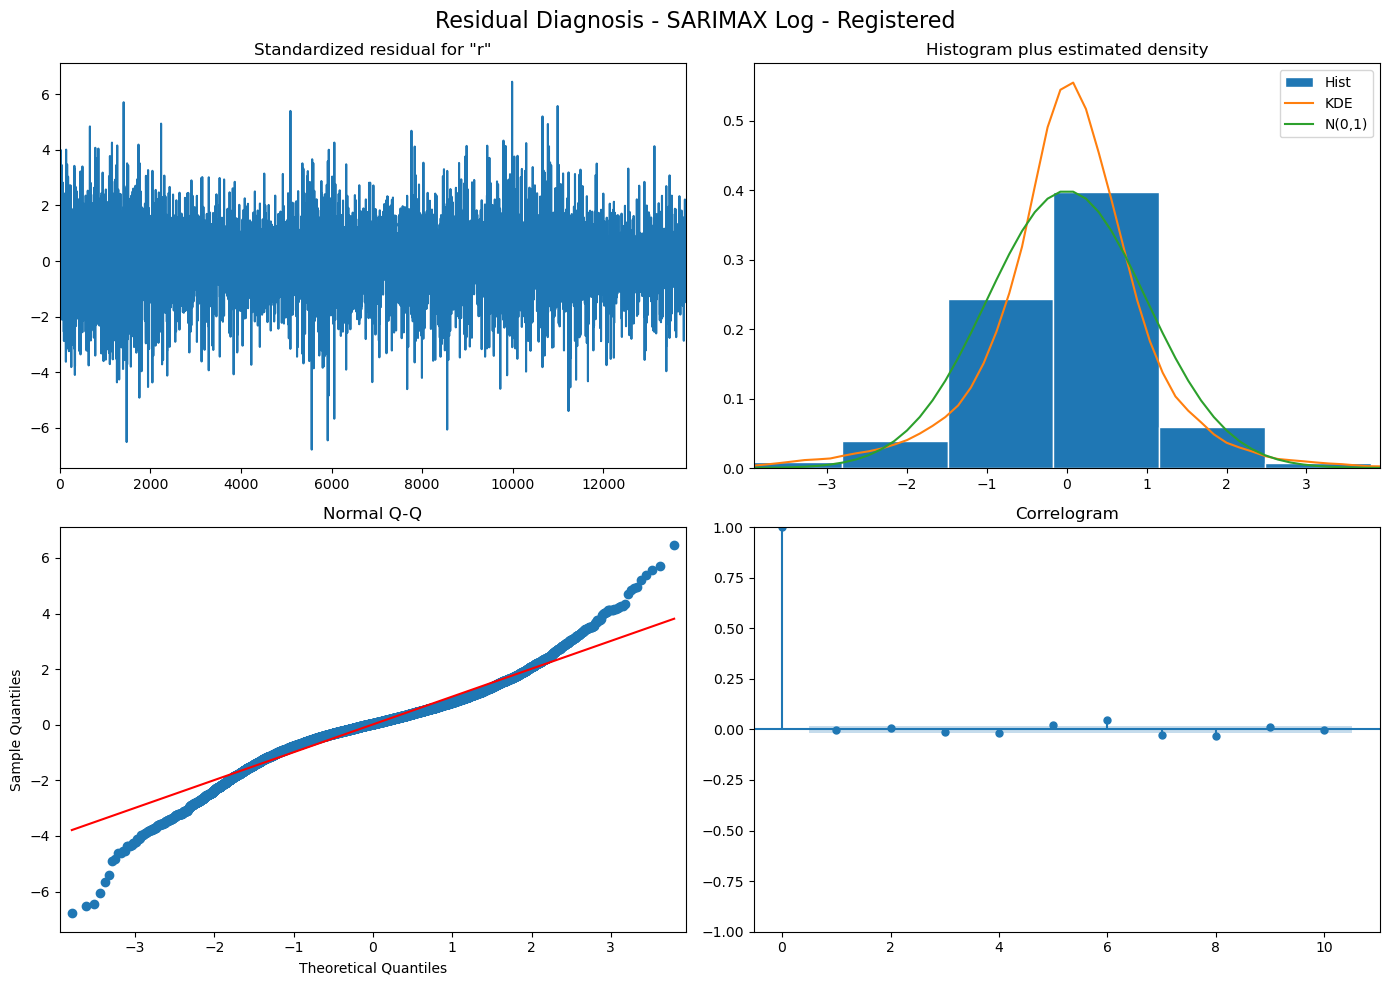


--- Ljung-Box Test (SARIMAX Log - Registered) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,95.618081,3.999582e-15
24,583.898958,5.518243e-108


In [13]:
residual_analysis(fit_sarimax_log_registered, "SARIMAX Log - Registered")

### Results

#### *Casual*

Starting Walk-Forward simulation (SARIMAX LOG - 24h)...


Simulated days:   0%|          | 0/145 [00:00<?, ?it/s]

WMAPE (SARIMAX Log - Casual): 34.94%


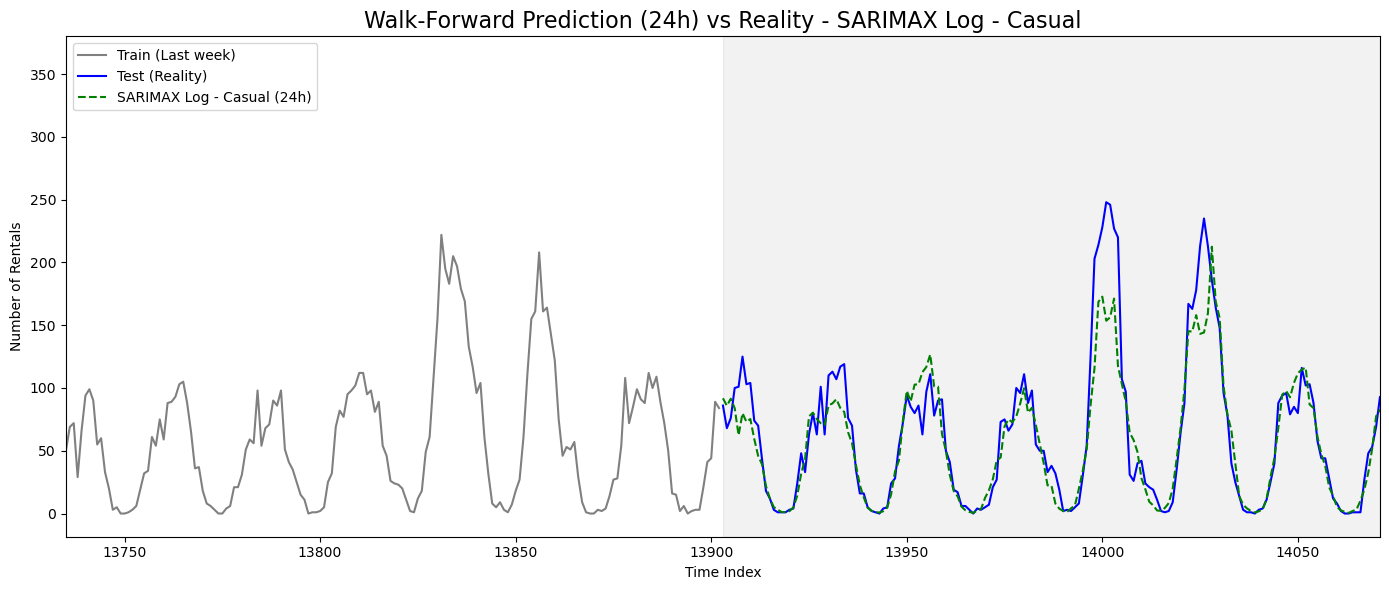

In [14]:
print("Starting Walk-Forward simulation (SARIMAX LOG - 24h)...")

pred_sarimax_log = walk_forward_predict(fit_sarimax_log, y_casual_test, step_size=24, X_test=X_test, log_transform=True)

evaluate_and_plot(y_casual_train, y_casual_test, pred_sarimax_log, "SARIMAX Log - Casual")

#### *Registered*

Simulated days:   0%|          | 0/145 [00:00<?, ?it/s]

WMAPE (SARIMAX Log - Registered): 31.17%


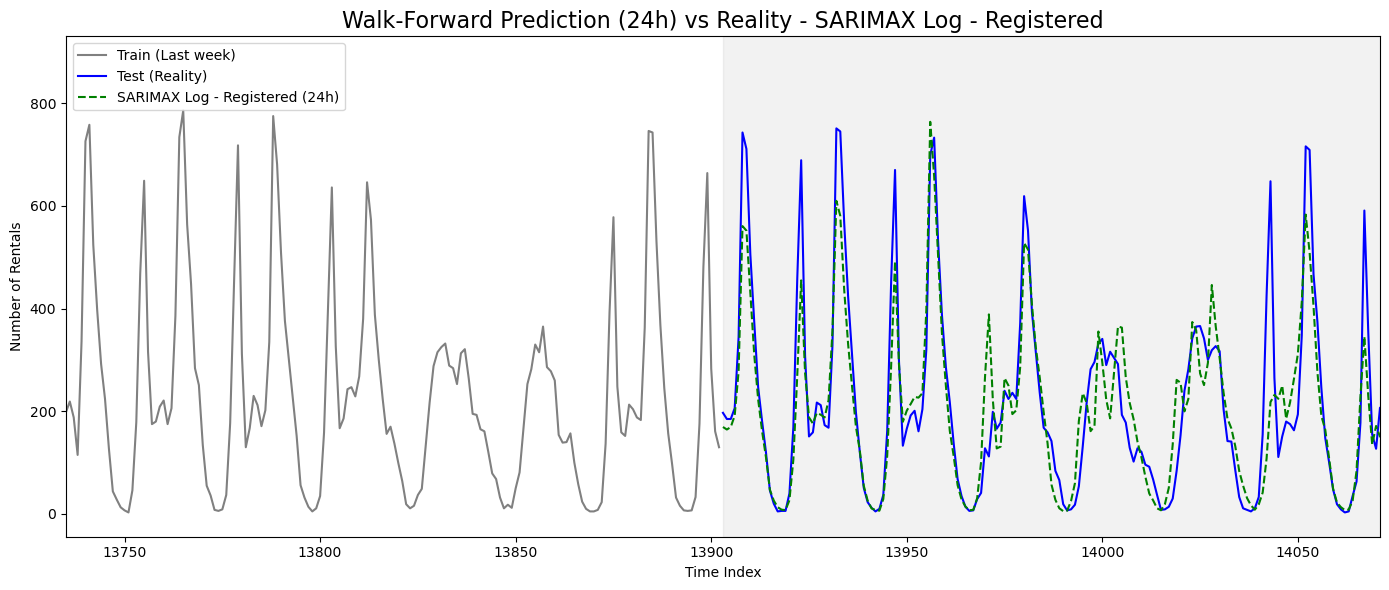

In [15]:
pred_sarimax_log_registered = walk_forward_predict(fit_sarimax_log_registered, y_registered_test, step_size=24, X_test=X_test, log_transform=True)
evaluate_and_plot(y_registered_train, y_registered_test, pred_sarimax_log_registered, "SARIMAX Log - Registered")

#### *Combined*

--- RENDIMIENTO GLOBAL (Casual + Registered) ---
MAE Global:        73.74 bikes/hour
WMAPE Global:      29.64%
Forecast Accuracy: 70.36%


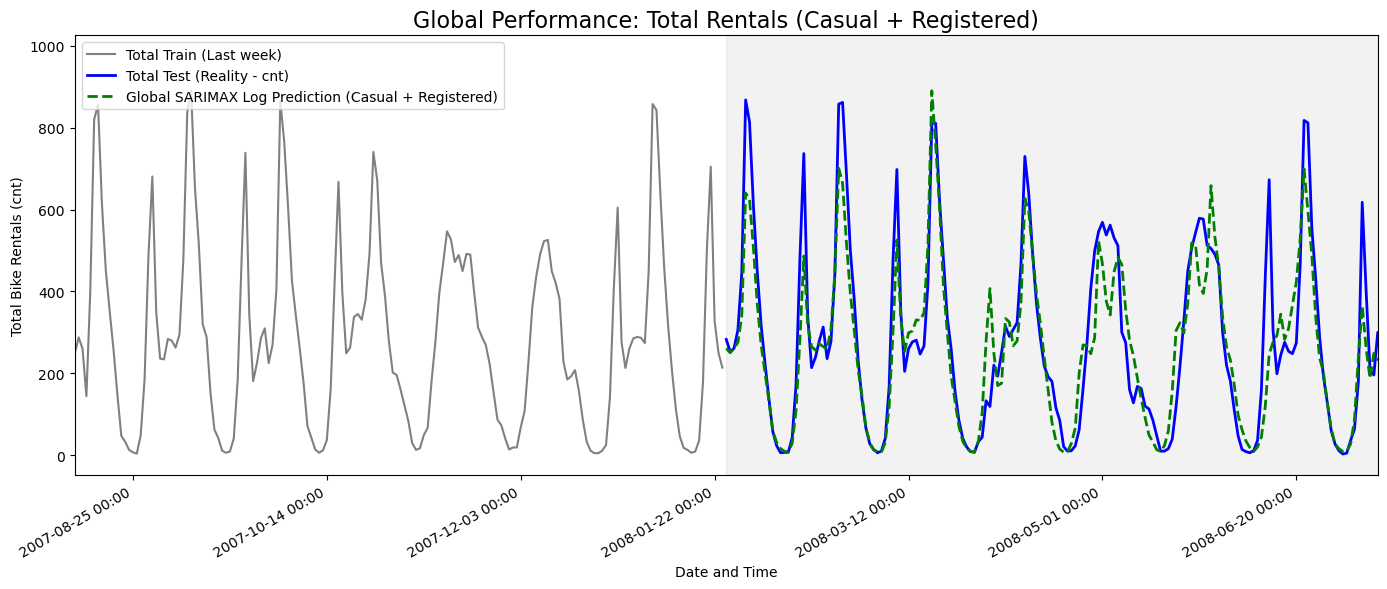

In [16]:
import matplotlib.dates as mdates

# 1. SERIES GLOBALES
total_pred_series = pred_sarimax_log + pred_sarimax_log_registered
y_total_test = y_casual_test + y_registered_test
y_total_train = y_casual_train + y_registered_train

# 2. MÉTRICAS GLOBALES
mae_total = np.sum(np.abs(y_total_test - total_pred_series)) / len(y_total_test)
wmape_total = np.sum(np.abs(y_total_test - total_pred_series)) / np.sum(y_total_test)

print("--- RENDIMIENTO GLOBAL (Casual + Registered) ---")
print(f"MAE Global:        {mae_total:.2f} bikes/hour")
print(f"WMAPE Global:      {wmape_total * 100:.2f}%")
print(f"Forecast Accuracy: {100 - (wmape_total * 100):.2f}%")

# 3. VISUALIZACIÓN
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_total_train.index[-168:], y_total_train.iloc[-168:],
        label='Total Train (Last week)', color='gray')
ax.plot(y_total_test.index, y_total_test,
        label='Total Test (Reality - cnt)', color='blue', linewidth=2)
ax.plot(total_pred_series.index, total_pred_series,
        label='Global SARIMAX Log Prediction (Casual + Registered)', color='green', linestyle='--', linewidth=2)

ax.axvspan(y_total_test.index[0], y_total_test.index[-1], color='#808080', alpha=0.1)
ax.set_title('Global Performance: Total Rentals (Casual + Registered)', fontsize=16)
ax.set_xlabel('Date and Time')
ax.set_ylabel('Total Bike Rentals (cnt)')
ax.legend(loc='upper left')
ax.set_xlim(y_total_train.index[-168], y_total_test.index[168])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## **SAVE MODELS**

In [17]:
#fit_casual_final.save('../models/sarima_casual_model.pkl')
#fit_registered_final.save('../models/sarima_registered_model.pkl')
fit_sarimax_log.save('../models/sarimax_casual_model.pkl')
fit_sarimax_log_registered.save('../models/sarimax_registered_model.pkl')